In [1]:
# simulation libs
from lib import params
import nest

import numpy as np
import matplotlib.pyplot as plt

import math

%load_ext autoreload
%autoreload 2


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Oct  2 2025 06:57:57

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [2]:
# Parameters
simtime = 1000.0  # Simulation time in ms
Is = [np.linspace(300.0, 400.0, 50), np.linspace(130.0, 180.0, 25), np.linspace(50.0, 100.0, 25)]

# Utility: sample numeric parameters from a normal distribution around nominal values
# Only perturb designated keys; keep all other parameters equal to nparam
def sample_params_uniform(base_params, designated_keys=None, scale=0.1):
    # start from a shallow copy of base_params so all keys keep nominal values
    samp = dict(base_params)
    if designated_keys is None:
        designated_keys = ['C_m', 'g_L', 'V_th', 't_ref', 'tau_syn_in']

    # Only modify the designated keys (if present and numeric)
    for k in designated_keys:
        if k in base_params and isinstance(base_params[k], (int, float, np.integer, np.floating)):
            v = base_params[k]
            # standard deviation proportional to nominal magnitude; fallback to 'scale' if v == 0
            sd = abs(v) * scale if v != 0 else scale
            val = np.random.normal(loc=v, scale=sd)
            if isinstance(v, int):
                val = int(round(val))
            samp[k] = val
    return samp

# Simulate F-I curve for a single parameter set
def simulate_fi_curve(param_set, I_values=None):
    rates = []
    for I in I_values:
        nest.ResetKernel()
        nrn = nest.Create('iaf_cond_alpha', 1, param_set)
        
        # params = nest.GetStatus(nrn)[0]  # GetStatus returns a list of dicts
        # for key, value in params.items():
        #     print(f"{key}: {value}")
        # assert False

        nest.SetStatus(nrn, {'I_e': I})
        spike_rec = nest.Create('spike_recorder')
        nest.Connect(nrn, spike_rec)
        nest.Simulate(simtime)
        spikes = nest.GetStatus(spike_rec, 'n_events')[0]
        firing_rate = spikes / (simtime / 1000.0)  # Hz
        rates.append(firing_rate)
    return np.array(rates)

# Sampling & simulation settings
N_samples = 100           # how many neurons to sample
scale = 1/30              # relative sampling range (±10%)
np.random.seed(42)       # reproducibility

fi_curves_all = {}
labels = ['MSN', 'FSI', 'GPE']
for idx, nparam in enumerate([params.paramMSN, params.paramFSI, params.paramGPE]):
    print(f"Neuron type: {labels[idx]}")
    param_keys = ['C_m', 'V_th', 'g_L', 't_ref']

    # Draw samples, simulate F-I curves
    fi_curves = []
    param_samples = []
    for i in range(N_samples):
        # pass nparam (base dict) and the designated param_keys list
        ps = sample_params_uniform(nparam, designated_keys=param_keys, scale=scale)
        param_samples.append(ps)
        freqs = simulate_fi_curve(ps, I_values=Is[idx])
        fi_curves.append(freqs)
    fi_curves = np.array(fi_curves)  # shape: (N_samples, len(I_values))

    fi_curves_all[labels[idx]] = {
        'fi_curves': fi_curves,
        'param_samples': param_samples,
    }

Neuron type: MSN

Dec 19 11:53:10 NodeManager::prepare_nodes [Info]: 
    Preparing 2 nodes for simulation.

Dec 19 11:53:10 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 2
    Simulation time (ms): 1000
    Number of OpenMP threads: 1
    Not using MPI

Dec 19 11:53:10 SimulationManager::run [Info]: 
    Simulation finished.

Dec 19 11:53:10 NodeManager::prepare_nodes [Info]: 
    Preparing 2 nodes for simulation.

Dec 19 11:53:10 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 2
    Simulation time (ms): 1000
    Number of OpenMP threads: 1
    Not using MPI

Dec 19 11:53:10 SimulationManager::run [Info]: 
    Simulation finished.

Dec 19 11:53:10 NodeManager::prepare_nodes [Info]: 
    Preparing 2 nodes for simulation.

Dec 19 11:53:10 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 2
    Simulation time (ms): 1000
    Number of OpenMP threads: 1
    Not using MPI

Dec 19 11:53:10 SimulationManager::run [Info]: 


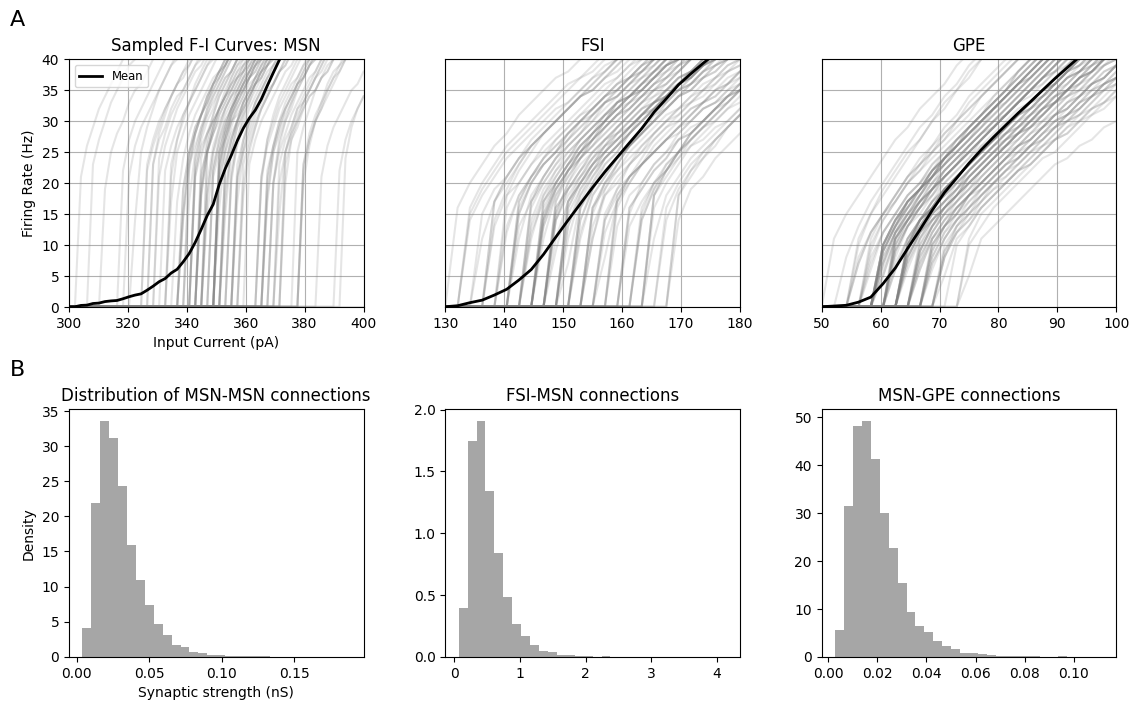

In [3]:
labels_fi = ['MSN', 'FSI', 'GPE']
xlims = [[300, 400], [130, 180], [50, 100]]

labels_conn = ['MSN-MSN', 'FSI-MSN', 'MSN-GPE']
Js = [0.03, 0.5, 0.02]
sigma = 0.5  # lognormal scale parameter

# ---- Figure with two subfigures (one per "panel") ----
fig = plt.figure(figsize=(12, 7))
subfig_fi, subfig_conn = fig.subfigures(nrows=2, ncols=1, hspace=0.0)

# =========================
# Top subfigure: F–I curves
# =========================
axes_fi = subfig_fi.subplots(nrows=1, ncols=3, sharey=True)

for ax, label in zip(axes_fi, labels_fi):
    idx = labels_fi.index(label)

    # Axis titles: first panel has expanded title, others just label
    ax.set_title(f'Sampled F-I Curves: {label}' if idx == 0 else label)

    fi_curves = fi_curves_all[label]['fi_curves']  # shape: (n_samples, len(Is[idx]))
    # Plot individual sampled curves
    for freqs in fi_curves:
        ax.plot(Is[idx], freqs, alpha=0.2, color='gray')

    # Plot mean curve
    mean_curve = fi_curves.mean(axis=0)
    ax.plot(Is[idx], mean_curve, color='k', linewidth=2, label='Mean')

    # Cosmetics
    ax.grid(True)
    ax.set_ylim(0, 40)
    ax.set_xlim(xlims[idx])

    if idx == 0:
        ax.text(-0.2, 1.2, 'A', transform=ax.transAxes, fontsize=16, va='top')
        ax.set_xlabel('Input Current (pA)')
        ax.set_ylabel('Firing Rate (Hz)')
        ax.legend(loc='upper left', fontsize='small')
    else:
        ax.tick_params(labelleft=False, left=False)

# ================================================
# Bottom subfigure: inhibitory synaptic distributions
# ================================================
axes_conn = subfig_conn.subplots(nrows=1, ncols=3)

for ax, label in zip(axes_conn, labels_conn):
    idx = labels_conn.index(label)
    # Lognormal parameters (mean on log-scale)
    mu = np.log(Js[idx]) - 0.5 * sigma**2
    samples = np.random.lognormal(mean=mu, sigma=sigma, size=10000)

    ax.hist(samples, bins=30, alpha=0.7, density=True, color='gray')

    if idx == 0:
        ax.text(-0.2, 1.2, 'B', transform=ax.transAxes, fontsize=16, va='top')
        ax.set_xlabel('Synaptic strength (nS)')
        ax.set_ylabel('Density')
        ax.set_title(f'Distribution of {label} connections')
    else:
        ax.set_title(f'{label} connections')

# Global layout
plt.tight_layout(rect=[0, 0.1, 1, 0.85])
plt.savefig('plot/hetero.pdf', dpi=500)
